# Task 2.1.6: Task 6: Object Detection using Selective Search
## The basics of object detection using selective search and its applications

The selective search technique for detecting objects.

In [1]:
# Importing required libraries, which include:
# OpenCV library used for the many tasks in computer vision, from loading images, to processing, detecting, shapes, tracking objects etc.:
import cv2
# Numpy is very useful computation library, here we can use it to compute means:
import numpy as np
# We need the following to show images as plots (x and y axes), later we will use it to draw actual plots too:
import matplotlib.pyplot as plt
# We need the following to draw areas of interest on our plots and images:
import matplotlib.patches as patches

In [2]:
# Load our image using PyTorch to handle the entire dataset and convert it to the appropriate format.
# This dataset contains many images which are used for training and then evaluating object detection methods.

from torchvision.datasets import VOCSegmentation
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

voc_segmentation_dataset = VOCSegmentation(root="./data", year="2012", image_set="train", transform=transform) #, download=True

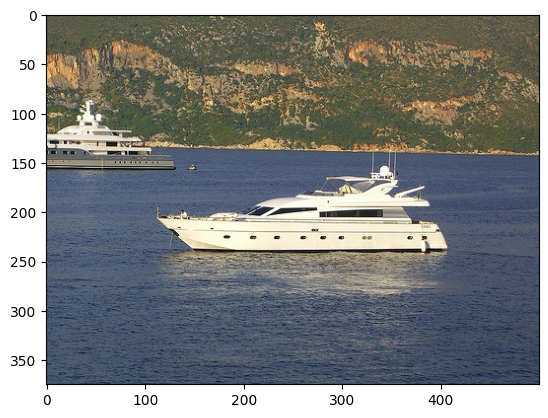

In [123]:
# Load a sample image
# Image 70 was chosen randomly, try changing the index used to test the following steps with a different image.
dataset_image_index = 70
img, seg_class = voc_segmentation_dataset[dataset_image_index]

image_rgb = img.permute(1, 2, 0).numpy()
plt.imshow(image_rgb)
plt.show()

In [125]:
# Use OpenCV to initialize and execute selective search on loaded image

# Initialize Selective Search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image_rgb)

# Fast but less accurate version: 'Fast'
# High accuracy but slower version: 'Quality'
ss.switchToSelectiveSearchQuality()

# Execute selective search and get proposed regions
proposals = ss.process()
print(f"{len(proposals)} region proposals generated.")

772 region proposals generated.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


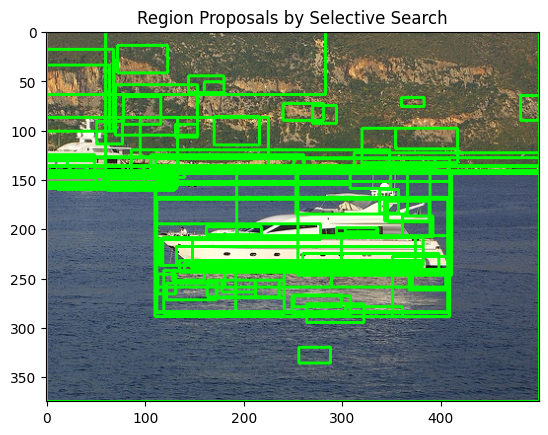

In [140]:
# It's not feasible to display all region proposals, as there could be thousands of them. Instead, we'll visualize a subset, say the first 100 proposals, to get an idea of how the algorithm is working:

# Copy the original image for visualization
output = image_rgb.copy()

# Loop over the region proposals (just the first 100 in this case) and draw them on our image
for i, rect in enumerate(proposals[:100]):
    x, y, w, h = rect
    cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2, cv2.LINE_AA)

# Visualize the output with region proposals drawn
plt.imshow(output)
plt.title("Region Proposals by Selective Search")
plt.show()

# The green boxes you see are the region proposals by Selective Search. It’s evident that the algorithm proposes regions of various scales and aspect ratios, which makes it versatile for object detection.

In [ ]:
# Apply a classifier. For this example, let's use the ResNet-50 model, pretrained on the ImageNet dataset.

import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50

# Load the pre-trained ResNet-50 model
model = resnet50(pretrained=True)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

In [142]:
# Define the function to classify a proposal
def classify_proposal(proposal_img):
    # Resize and preprocess the proposal for ResNet-50
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    proposal_img = transform(proposal_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(proposal_img)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        max_score, max_class = probabilities.max(dim=1)
    
    return int(max_class), float(max_score)

# Define a function for NMS
def non_maximum_suppression(proposals, scores, threshold=0.3):
    if len(proposals) == 0:
        return []

    # Convert proposals coordinates to format (x1, y1, x2, y2)
    proposals = np.array([(x, y, x+w, y+h) for (x, y, w, h) in proposals])
    scores = np.array(scores)

    # Sort proposals by scores in descending order
    idxs = np.argsort(scores)[::-1]

    pick = []  # List of indices of final proposals
    while len(idxs) > 0:
        # Get the index of the current highest score
        current = idxs[0]
        pick.append(current)

        # Find the coordinates of intersection
        xx1 = np.maximum(proposals[current, 0], proposals[idxs[1:], 0])
        yy1 = np.maximum(proposals[current, 1], proposals[idxs[1:], 1])
        xx2 = np.minimum(proposals[current, 2], proposals[idxs[1:], 2])
        yy2 = np.minimum(proposals[current, 3], proposals[idxs[1:], 3])

        # Compute width and height of intersection
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        # Compute the ratio of intersection over union
        intersection = w * h
        union = (proposals[current, 2] - proposals[current, 0] + 1) * (proposals[current, 3] - proposals[current, 1] + 1) + \
                (proposals[idxs[1:], 2] - proposals[idxs[1:], 0] + 1) * (proposals[idxs[1:], 3] - proposals[idxs[1:], 1] + 1) - intersection
        iou = intersection / union

        # Keep only the proposals that have IoU less than the threshold
        idxs = np.delete(idxs, np.concatenate(([0], np.where(iou > threshold)[0] + 1)))

    return [proposals[p] for p in pick]

Now we are ready to classify the proposals generated by our **Selective Search** algorithm and visualize the best results. This following step is computationally more intensive and may take a couple minutes to complete.

In [ ]:
# Classify proposals and collect scores
proposal_scores = []
resized_proposals = []
best_predictions = []

for rect in proposals:
    x, y, w, h = rect
    proposal_image = img[:, y:y+h, x:x+w]
    prediction, score = classify_proposal(proposal_image)
    
    proposal_scores.append(score)
    resized_proposals.append(rect)
    best_predictions.append(prediction)

In the following code we apply NMS and visualize the best results. Try changing the values for the ***threshold*** as well as how many ***best_proposals_NMS*** items we view.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


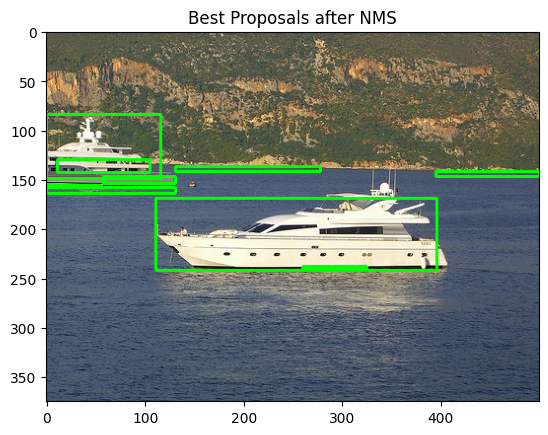

In [144]:
# Pick top X proposals
sorted_idxs = np.argsort(proposal_scores)[::-1]
topN_idxs = sorted_idxs

topN_proposals = [resized_proposals[i] for i in topN_idxs]
topN_scores = [proposal_scores[i] for i in topN_idxs]

# Apply non-maximum suppression
best_proposals_NMS = non_maximum_suppression(topN_proposals, topN_scores, threshold=0.25)
best_proposals = best_proposals_NMS[1:10]

# Visualize the best proposals
output_best = image_rgb.copy()

for rect in best_proposals:
    x1, y1, x2, y2 = rect
    cv2.rectangle(output_best, (x1, y1), (x2, y2), (0, 255, 0), 2, cv2.LINE_AA)

plt.imshow(output_best)
plt.title("Best Proposals after NMS")
plt.show()


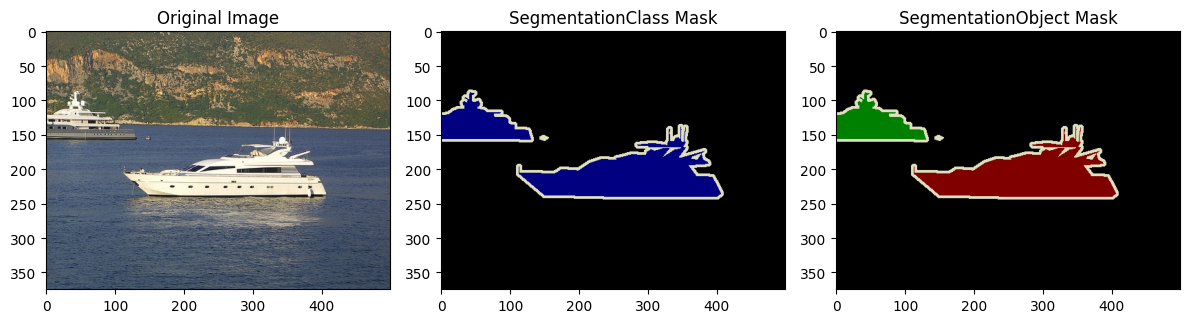

In [88]:
# Segmentation Masks

from PIL import Image
import os

# Access the SegmentationClass mask
img, seg_class = voc_segmentation_dataset[70]

# Construct the path to the SegmentationObject for the same image
image_name = voc_segmentation_dataset.images[70].split('/')[-1].split('.')[0].split('\\')[-1]
seg_object_path = os.path.join("./data", "VOCdevkit", "VOC2012", "SegmentationObject", image_name + ".png")

# Open using PIL
seg_object = Image.open(seg_object_path)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(seg_class)
plt.title('SegmentationClass Mask')

plt.subplot(1, 3, 3)
plt.imshow(seg_object)
plt.title('SegmentationObject Mask')

plt.tight_layout()
plt.show()

Task - Using OpenCV implement selective search on an image of your choice. Display the first n (n=10,50,100,200) proposals overlayed on the image.

In [ ]:
# Load an image

# Initialize the selective search algorithm

# Get the initial region proposals generated by selective search

# Set the number of region proposals to display at different stages (first n proposals)
num_to_show = [10, 50, 100, 200]

# Loop through the different stages to visualize region proposals

# Plot the image with the region proposals at the current stage

Bonus/Advanced Task - Use Scikit-image to manually segment an image and then group the segments hierarchically based on their average color value, display the results at each grouping stage.

In [ ]:
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.color import label2rgb

def get_average_color(image, labels, label):
    mask = labels == label
    region = image[mask]
    average_color = region.mean(axis=0)
    return average_color

def find_most_similar_pair(image, labels):
    unique_labels = np.unique(labels)
    min_distance = float('inf')
    most_similar_pair = None
    for i, label1 in enumerate(unique_labels):
        for label2 in unique_labels[i+1:]:
            color1 = get_average_color(image, labels, label1)
            color2 = get_average_color(image, labels, label2)
            distance = np.linalg.norm(color1 - color2)
            if distance < min_distance:
                min_distance = distance
                most_similar_pair = (label1, label2)
    return most_similar_pair

# Load an image

# Generate initial segments using SLIC superpixels

# Plot the initial segmentation

# Perform hierarchical grouping
for i in range(2): # Adjust the number of iterations as needed
    # Find the most similar pair of regions to merge
    
    # Merge the most similar pair of regions

    # Plot the result of the current merging step
